# Computing Love numbers, step by step

The **Kelvin sphere** is a uniform-density, self-gravitating elastic ball. Its Love numbers are:

$$h_2 = \frac{5/2}{1+\tilde\mu}, \qquad l_2 = \frac{3/4}{1+\tilde\mu}, \qquad
k_2 = \frac{3/2}{1+\tilde\mu}, \qquad \tilde\mu = \frac{19\mu}{2\rho g R}.$$

We take rigidity $\tilde\mu = 1$, so the targets are exactly $1.25,\ 0.375,\ 0.75$.


In [1]:
using Pkg; Pkg.activate(@__DIR__)
using Melinoe, ApproxFun, PyPlot, Printf, LinearAlgebra

# uniform sphere: ρ = 1, g(r) = r, rigidity μ̃ = 1, nearly incompressible (κ̃ large)
m = Melinoe.Models.Kelvin(μ̃ = 1.0, κ̃ = 1e6)
ℓ = 2
m


  Activating project at `~/code/ge-julia/examples`


PlanetModel("Kelvin", 1 layers, R=6371.0 km, ρ̄=5515.0 kg/m³)

## 1 · What a Love number is

An external tidal potential $\Phi_T(r)\,Y_\ell^m$ deforms the body. We take the
unit-amplitude harmonic

$$\Phi_T(r) = r^\ell \qquad (\Phi_T(R)=1).$$

The body responds with a **radial displacement** $U(r)$, a **tangential
displacement** $V(r)$, and a **self-gravity perturbation** $\delta\phi(r)$. The
three surface Love numbers read those responses at $r=R$:

$$h = U(R), \qquad l = V(R), \qquad k = \delta\phi(R).$$

So computing Love numbers = solving for $U,\ V,\ \delta\phi$ under $\Phi_T$, then
evaluating at the surface. Everything below builds that solve.


## 2 · The three equations

Expanding the fields on a single spherical harmonic $Y_\ell^m$, the static
($\omega=0$) problem is three coupled radial ODEs in $(U,\,V,\,\delta\phi)$:

$$\begin{aligned}
&\textbf{radial momentum:} && \nabla\!\cdot\!\sigma|_r - \rho_0\,\partial_r(\delta\phi+\Phi_T) = 0,\\[2pt]
&\textbf{tangential momentum:} && \nabla\!\cdot\!\sigma|_\theta - \tfrac{\rho_0}{r}(\delta\phi+\Phi_T) = 0,\\[2pt]
&\textbf{Poisson:} && \nabla^2\delta\phi = 3\,\delta\rho .
\end{aligned}$$

where the stress $\sigma$ carries the elastic moduli $\kappa,\mu$. Two practical
points the code bakes in:

- **Units.** Lengths $/R$, densities $/\bar\rho$, so $G = 3/(4\pi)$ and $g(1)=1$.
  Gravity $g(r)$ is *derived* from $\rho_0$, never supplied.
- **Fluid layers.** If $\mu=0$ the tangential equation loses its shear term and
  degenerates; there the code swaps $V$ for the pressure $P=-\kappa\nabla\!\cdot\!\mathbf u$.
  A solid — like this sphere — keeps $V$. Same 3×3 structure either way.


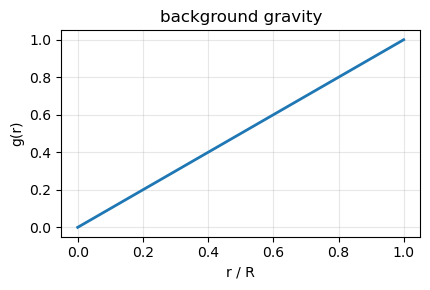

In [2]:
# g(r) is built from ρ₀; for the uniform sphere it is exactly r.
rr = range(0, 1, length=100)
fig, ax = subplots(figsize=(4.4, 3.0))
ax.plot(rr, [m.layers[1].g₀(r) for r in rr], lw=2)
ax.set_xlabel("r / R"); ax.set_ylabel("g(r)"); ax.set_title("background gravity")
ax.grid(alpha=0.3); tight_layout(); gcf()


## 3 · Each equation → a block operator

After projecting on $Y_\ell^m$ and clearing the $1/r$ singularities (multiply each
row by a power of $r$), every equation becomes a **row of linear operators** acting
on the three fields. The system is a 3×3 block:

$$\begin{pmatrix} A_{11}&A_{12}&A_{13}\\ A_{21}&A_{22}&A_{23}\\ A_{31}&A_{32}&A_{33}\end{pmatrix}
\begin{pmatrix} U\\ V\\ \delta\phi \end{pmatrix} = \mathbf f .$$

Row 1 = radial momentum, row 2 = tangential momentum, row 3 = Poisson. Two blocks
worth remembering — they are how a potential exerts force:

$$A_{13} = r^3\rho_0\,\partial_r, \qquad A_{23} = r^2\rho_0 .$$

In code the blocks carry **field names**, not index numbers — `A_UU … A_φφ` (row-equation × column-field) — so `A_{13}` is `A_Uφ` and `A_{33}` is `A_φφ`.

`gravitoelastic_blocks` builds them per layer, each discretised as an $n\times n$
**Chebyshev** matrix.


In [3]:
o = gravitoelastic_blocks(m.layers[1], ℓ, true)   # is_inner=true (this layer reaches r=0)
N = m.layers[1].n
@printf("solid layer (fluid=%s)     n = %d  spectral coeffs per field\n", o.fluid, N)
@printf("each block is %s.   Blocks: A_UU A_UV A_Uφ / A_VU A_VV A_Vφ / A_φU A_φV A_φφ\n", size(o.A_UU))
@printf("A_Uφ = r³ρ₀·D  →  A_Uφ[1:3,1:3] =\n"); show(stdout, "text/plain", round.(o.A_Uφ[1:3,1:3], digits=4))


solid layer (fluid=false)     n = 60  spectral coeffs per field
each block is (60, 60).   Blocks: A_UU A_UV A_Uφ / A_VU A_VV A_Vφ / A_φU A_φV A_φφ
A_Uφ = r³ρ₀·D  →  A_Uφ[1:3,1:3] =
3×3 Matrix{Float64}:
 0.0  0.3333  0.5303
 0.0  0.2727  0.6818
 0.0  0.1111  0.4915

### How a block is built — ApproxFun

The $A_{ij}$ are never typed out as numbers. Each is assembled **symbolically** on
the layer's spectral space from two primitives — the radius as a function and the
derivative operator — then truncated to a matrix:

```julia
S = ...                     # the layer's spectral space
r = Fun(identity, S)        # radius, as a multiplication operator
D = Derivative(S)           # differentiation operator
ρ₀ = Fun(layer.ρ₀, S)       # background fields become Funs too
```

Every block is then an **$r$-polynomial times powers of $D$**. The Poisson block is
the cleanest — the $\ell$-transformed radial Laplacian:

$$A_{33} = r^2 D^2 + 2r\,D - \ell(\ell+1).$$

An operator is a genuine linear map on functions, so we can *apply* it: $r^\ell
Y_\ell$ is harmonic, so $A_{33}$ must annihilate $r^\ell$. Truncating to a matrix is
`Matrix(op[1:n, 1:n])` — but first a subtlety: $D$ maps $S$ to a *different* space,
so blocks are `Conversion`-ed to a common rangespace before they can be stacked.


In [4]:
S = o.S                              # this layer's spectral space
r = Fun(identity, S); D = Derivative(S)
A33 = r^2*D^2 + 2r*D - ℓ*(ℓ+1)       # ℓ-transformed radial Laplacian

@printf("‖A33 · r^ℓ‖ = %.1e     (r^ℓ is harmonic ⇒ 0)\n", norm(A33 * Fun(x->x^ℓ, S)))
@printf("rangespace(A33) ≠ S ?  %s   ⇒ Conversion needed before stacking\n", rangespace(A33) != S)


‖A33 · r^ℓ‖ = 1.9e-16     (r^ℓ is harmonic ⇒ 0)
rangespace(A33) ≠ S ?  true   ⇒ Conversion needed before stacking


### Regularity at the centre

At $r=0$ the radial Laplacian $r^2u''+2ru'-\ell(\ell+1)u=0$ has a **regular** branch
$u\sim r^\ell$ and a **singular** one $u\sim r^{-\ell-1}$; a physical field is regular.
With a single degree $\ell$, the basis handles this: the innermost layer uses a
**Jacobi $P_n^{(0,\ell)}$** expansion (not Chebyshev), which builds in the $r^\ell$
behaviour — so the centre needs no boundary row, unlike every interface and the surface.

> When *many* harmonic degrees couple (rotating-fluid modes), one instead double-covers
> the centre — the **parity trick**. A single-$\ell$ problem like this doesn't need it.


In [5]:
println("centre-layer space: ", o.S, "   (Jacobi, not Chebyshev)")
rg = interior_ranges(1, N, false, N, [0, N])
@printf("operator rows start at row %d  ⇒  %d rows reserved at r=0  (regularity is free)\n",
        first(rg.U_int), first(rg.U_int) - 1)


centre-layer space: Jacobi(0,2,0.0 .. 1.0)   (Jacobi, not Chebyshev)
operator rows start at row 1  ⇒  0 rows reserved at r=0  (regularity is free)


## 4 · Assembly: stack the blocks, cap with boundary rows

We built one block, $A_{33}$, from scratch; `gravitoelastic_blocks` builds all nine the
same way. **Assembly** is then mechanical: drop the nine $N\times N$ blocks into a
$3N\times3N$ matrix (one block per equation × field), then overwrite the **last row
of each field** with a boundary condition — an ODE needs its BCs. For this single
layer the three capping rows are the free-surface conditions:

| block | interior rows | last (capping) row |
|---|---|---|
| $U$ | radial-momentum operator | $\sigma_{rr}=0$ |
| $V$ | tangential-momentum operator | $\sigma_{r\theta}=0$ |
| $\delta\phi$ | Poisson operator | $\delta\phi'+\tfrac{\ell+1}{r}\delta\phi=0$ |

`surface_bc_rows` returns those rows. A multi-layer model reserves more rows for
interface continuity; the centre needs none (Jacobi basis). Let's build it by hand —
this **is** `assemble_planet`, minus a harmless rescaling of the capping rows.


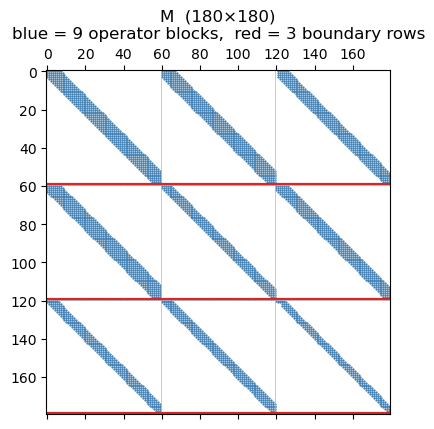

In [6]:
Ur, Vr, dr = 1:N, N+1:2N, 2N+1:3N
M = zeros(3N, 3N)                                    # 1) drop in the nine blocks
M[Ur,Ur], M[Ur,Vr], M[Ur,dr] = o.A_UU, o.A_UV, o.A_Uφ
M[Vr,Ur], M[Vr,Vr], M[Vr,dr] = o.A_VU, o.A_VV, o.A_Vφ
M[dr,Ur], M[dr,Vr], M[dr,dr] = o.A_φU, o.A_φV, o.A_φφ

bc = surface_bc_rows(o.S, o.D, N, ℓ, m.layers[1].κ, m.layers[1].μ, m.layers[1].ρ₀, 1.0)
M[N, :] .= 0;  M[N, Ur],  M[N, Vr] = vec(bc.σrr_U),  vec(bc.σrr_V)    # 2) cap last row
M[2N,:] .= 0;  M[2N,Ur],  M[2N,Vr] = vec(bc.σrθ_U),  vec(bc.σrθ_V)    #    of each field
M[3N,:] .= 0;  M[3N,Ur],  M[3N,dr] = vec(bc.grav_U), vec(bc.grav_δφ)  #    with a BC

fig, ax = subplots(figsize=(4.4, 4.4))
ax.spy(M, markersize=0.6, color="steelblue")
for b in (N, 2N); ax.axvline(b-0.5, color="0.7", lw=0.5); ax.axhline(b-0.5, color="0.7", lw=0.5); end
for r in (N, 2N, 3N); ax.axhline(r-1, color="C3", lw=1.6); end
ax.set_title("M  ($(3N)×$(3N))\nblue = 9 operator blocks,  red = 3 boundary rows")
tight_layout(); gcf()


## 5 · The tidal forcing

Newton's law carries the external potential as the body force $-\rho_0\nabla\Phi_T$
— structurally identical to how $\delta\phi$ acts. So the right-hand side is just
the $\delta\phi$-column operators applied to $\Phi_T = r^\ell$:

$$f_U = -A_{13}\,\mathbf v_{\Phi}, \qquad f_V = -A_{23}\,\mathbf v_{\Phi},$$

with $\mathbf v_\Phi$ the Chebyshev coefficients of $r^\ell$. Poisson gets nothing
(a harmonic $\Phi_T$ has no density source). That is all of `potential_forcing`.


In [7]:
f = potential_forcing([o], [N]; ℓ)
@printf("nonzeros:  U-rows %d   V-rows %d   δφ-rows %d  (Poisson unforced)\n",
        count(!=(0), f[1:N]), count(!=(0), f[N+1:2N]), count(!=(0), f[2N+1:3N]))


nonzeros:  U-rows 5   V-rows 5   δφ-rows 0  (Poisson unforced)


## 6 · Solve, and read the surface

One linear solve gives all three fields; split the vector into Chebyshev `Fun`s and
evaluate at $r=1$. The profiles are smooth and physical — a solid has no interior
ambiguity (see the note at the end on why a *fluid* sphere would not).


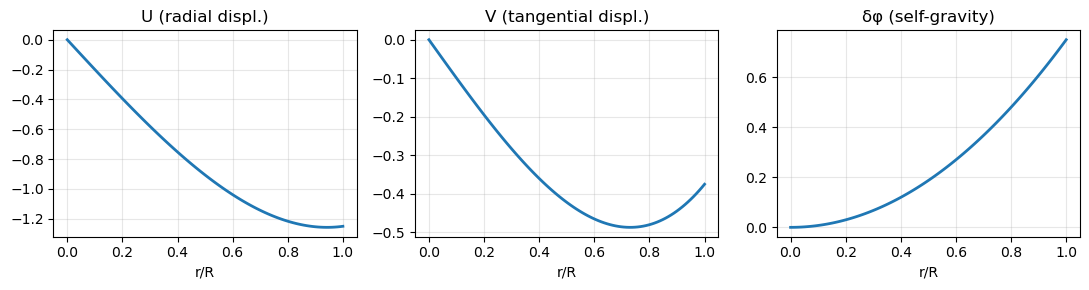

In [8]:
x = M \ f                              # solve the matrix we just built
U  = Fun(o.S, x[1:N])
V  = Fun(o.S, x[N+1:2N])
δφ = Fun(o.S, x[2N+1:3N])

fig, ax = subplots(1, 3, figsize=(11, 3.0))
for (a, y, t) in zip(ax, (U, V, δφ), ("U (radial displ.)", "V (tangential displ.)", "δφ (self-gravity)"))
    a.plot(rr, [y(r) for r in rr], lw=2); a.set_xlabel("r/R"); a.set_title(t); a.grid(alpha=0.3)
end
tight_layout(); gcf()


In [9]:
# code carries g inward ⇒ U, V come out negative; report |h|, |l|
h = -U(1.0); l = -V(1.0); k = δφ(1.0)
@printf("h = %.6f   (exact 5/2/(1+μ̃) = 1.25)\n", h)
@printf("l = %.6f   (exact 3/4/(1+μ̃) = 0.375)\n", l)
@printf("k = %.6f   (exact 3/2/(1+μ̃) = 0.75)\n", k)

ln = love_numbers(m)   # the library one-liner — same pipeline, same numbers
@printf("\nlove_numbers(m):  h = %.6f   l = %.6f   k = %.6f\n", -ln.h, -ln.l, ln.k)


h = 1.250000   (exact 5/2/(1+μ̃) = 1.25)
l = 0.375000   (exact 3/4/(1+μ̃) = 0.375)
k = 0.750000   (exact 3/2/(1+μ̃) = 0.75)

love_numbers(m):  h = 1.250000   l = 0.375000   k = 0.750000
